# Exploratory Data Analysis Organized

In [1]:
print('Kernel test 1233')

Kernel test 1233


In [2]:
# Step 0, lets import the regular stuff we will probably need
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
summarize)
print('Done part 1212323')

# MORE MOUSE BITES
# Ehh, we should really start learning SCIKITLEARN next or whatever its called
# but I think for this project its not horrible to stick with the ISLP resources
# since we ARE straying from the notes now
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
(LinearDiscriminantAnalysis as LDA ,
QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

print('Done part 2 with gitt')

Done part 1212323
Done part 2 with gitt


In [3]:
# Import the data:
Titanic_train = pd.read_csv('titanic_data/train.csv')

Titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Here is the summary of our EDA.

<img src="images_titanic/EDA summary.png" width="1300">

The plan is this:

 1(a)Drop 'PassengerId' column

 1(b) Create column called 'Title' to estimate the missing ages. Estimate missing ages

 1(c) Combine SibSp and ParCh columns into one (SibSp + ParCh). Then make it into bins (we dont want bins that are too small, to avoid overfitting). Drop 'SibSP', 'ParCh' columns as well as any created temporarily to calculate this Family_Bins style column

 1(d) Make 'Has_Cabin_Record' column. Drop 'Cabin' column 

 1(e) Use ticket to calculate log+1(Fare). Create 'log_plus1_Fare' column. Drop 'Fare' and 'Ticket' columns.

 1(f) Delete the rows where 'Embarked' is null. Setup so that for future training, we assume Embarked = Mode (S?)

In [4]:
#1(a)

# We drop the useless looking column
Titanic_train = Titanic_train.drop(columns='PassengerId')

Titanic_train.head()

print('hello')

hello


In [5]:
# 1(b)

print('The median age  was ' + str(Titanic_train['Age'].median()))

# Then we use regex to find the different groups, and make a new column. The column we care about is 'Name', we categorize according to cat we found and what google says they mean
conditions_name = [
    Titanic_train['Name'].str.contains(r'Master') 
    , Titanic_train['Name'].str.contains(r'Mrs.') | Titanic_train['Name'].str.contains(r'Mme.')# Married woman Mme
    , Titanic_train['Name'].str.contains(r'Mr.') # Mr.
    , Titanic_train['Name'].str.contains(r'Miss.') | Titanic_train['Name'].str.contains(r'Mlle.') # Girl or unmarried woman, Unmarried
]

choices_name = ['Master'
                , 'Mrs/Mme'
                , 'Mr'
                , 'Miss/Mlle']

Titanic_train['Title'] = np.select(conditions_name, choices_name, default = 'Other')

# We review the value counts, Other is a BIT suspect in terms of being too small a category, but since we are using this for age estimation as opposed to category, I think this is ok
Titanic_train['Title'].value_counts()

Titanic_train['Age'] = Titanic_train['Age'].fillna(
    Titanic_train.groupby('Title')['Age'].transform('median')
)

print('The median age has changed to be ' + str(Titanic_train['Age'].median()))

The median age  was 28.0
The median age has changed to be 30.0


In [6]:
# 1(c)
Titanic_train['Family'] = Titanic_train['SibSp']+Titanic_train['Parch']

# Create bins for SibSp and ParCh
bins_01_2 = [-0.5, 0.5, 1.5, 1000]
labels_01_2 = ['Zero', 'One', 'Two or more']

# Create bins for "Family"
bins_012_3 = [-0.5, 0.5, 1.5, 2.5, 1000]
labels_012_3 = ['Zero', 'One', 'Two', 'Three or more']

Titanic_train['Sibsp_bins'] = pd.cut(Titanic_train['SibSp'], bins_01_2, labels = labels_01_2)
Titanic_train['Parch_bins'] = pd.cut(Titanic_train['Parch'], bins_01_2, labels = labels_01_2)
Titanic_train['Family_bins'] = pd.cut(Titanic_train['Family'], bins_012_3, labels = labels_012_3)
Titanic_train.head(10)

# Drop actual values. Bins to be decided later
Titanic_train = Titanic_train.drop(columns='SibSp')
Titanic_train = Titanic_train.drop(columns='Parch')
Titanic_train = Titanic_train.drop(columns='Family')

In [7]:
# 1(d)
Titanic_train['Has_Cabin_Record'] = Titanic_train['Cabin'].notna().astype(int)

Titanic_train = Titanic_train.drop(columns='Cabin')

In [8]:
# 1(e)

ticket_counts = Titanic_train['Ticket'].value_counts()
group_size_by_ticket = Titanic_train['Ticket'].map(ticket_counts)

Titanic_train['Individual_Fare_LogPlus1'] = np.log1p(Titanic_train['Fare'] / group_size_by_ticket)

Titanic_train = Titanic_train.drop(columns='Fare')
Titanic_train = Titanic_train.drop(columns='Ticket')

In [9]:
# 1(f)
Titanic_train = Titanic_train.dropna(subset=['Embarked'])

# 1(g) (For test data:) Fill missing 'Embarked' values in the test set with 'S'
#Titanic_test['Embarked'] = Titanic_test['Embarked'].fillna('S')

In [10]:
# 1(g) 
Titanic_train = Titanic_train.drop(columns='Name')
Titanic_train = Titanic_train.drop(columns='Title')

In [11]:
# 1(h) 
# Change the data type of some of the columns to the 'category' data type to make them easier to manipulate.
Titanic_train['Sex'] = Titanic_train['Sex'].astype('category')
Titanic_train['Embarked'] = Titanic_train['Embarked'].astype('category')

# Force Family_bins to be an UNORDERED category so MS() generates dummy variables. Thank you Gemini
Titanic_train['Family_bins'] = pd.Categorical(
    Titanic_train['Family_bins'], 
    categories=['Zero', 'One', 'Two', 'Three or more'], 
    ordered=False
)

# Again thank you Gemini for this change in datatype.
Titanic_train['Sibsp_bins'] = pd.Categorical(Titanic_train['Sibsp_bins'], ordered=False)
Titanic_train['Parch_bins'] = pd.Categorical(Titanic_train['Parch_bins'], ordered=False)
Titanic_train['Pclass']=pd.Categorical(Titanic_train['Pclass'], ordered=False)

In [12]:
# Final checkup
Titanic_train

,Survived,Pclass,Sex,Age,Embarked,Sibsp_bins,Parch_bins,Family_bins,Has_Cabin_Record,Individual_Fare_LogPlus1
0,0,3,male,22.0,S,One,Zero,One,0,2.110213
1,1,1,female,38.0,C,One,Zero,One,1,4.280593
2,1,3,female,26.0,S,Zero,Zero,Zero,0,2.188856
3,1,1,female,35.0,S,One,Zero,One,1,3.316003
4,0,3,male,35.0,S,Zero,Zero,Zero,0,2.202765
...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,S,Zero,Zero,Zero,0,2.639057
887,1,1,female,19.0,S,Zero,Zero,Zero,1,3.433987
888,0,3,female,21.0,S,One,Two or more,Three or more,0,2.543569
889,1,1,male,26.0,C,Zero,Zero,Zero,1,3.433987


In [13]:
# So the question becomes 'how do we choose which model to use to train the data'. Well lets list out the possible models that chapter 4 has given us:
# Logistic Regression
# Linear Discriminant Analysis
# Quadratic Discriminant Analysis
# Naive Bayes
# KNN

# Most likely its gonna be QDA but it could be LDA or even Logistic Regression.
# I doubt it will be KNN due to the number of predictor parameters and the comparative lack of data
# As for Naive Bayes I dont even remember what that one is but it sounds not very flexible. We can look into it.

# So, plan is to fit the model with LR, LDA and QDA. Then investigate Naive Bayes Definition.,

# Then compare model fit using cross validation in 5 groups (the standard)

# Pick the model which has the best Cross-Validation results.

# Fit the data. Kachapaow! Donezo.

# Logistic Regression:

#Titanic_train.describe()

# Titanic train with family column
Titanic_train_f = Titanic_train.copy()
Titanic_train_f  = Titanic_train_f.drop(columns='Sibsp_bins')
Titanic_train_f  = Titanic_train_f.drop(columns='Parch_bins')


# Titanic train with siblings-spouse and parent-child columns
Titanic_train_sp = Titanic_train.copy()
Titanic_train_sp  = Titanic_train_sp.drop(columns='Family_bins')



# Titanic train data for Family version, without the response
Titanic_train_LR_f = Titanic_train_f.copy()
Titanic_train_LR_f  = Titanic_train_f.drop(columns='Survived')

# Titanic train data for SibSpouse-ParChild version, without the response
Titanic_train_LR_sp = Titanic_train_sp.copy()
Titanic_train_LR_sp  = Titanic_train_sp.drop(columns='Survived')


design_LR_f = MS(Titanic_train_LR_f)
design_LR_sp = MS(Titanic_train_LR_sp)

X_LR_f = design_LR_f.fit_transform(Titanic_train_f)
X_LR_sp = design_LR_sp.fit_transform(Titanic_train_sp)

Y_LR_f = Titanic_train_f.Survived == 1
Y_LR_sp = Titanic_train_sp.Survived == 1

glm_LR_f = sm.GLM(Y_LR_f, X_LR_f, family=sm.families.Binomial())
glm_LR_sp = sm.GLM(Y_LR_sp, X_LR_sp, family=sm.families.Binomial())

results_LR_f = glm_LR_f.fit()
results_LR_sp = glm_LR_sp.fit()

summarize(results_LR_f)

#Titanic_train_f

# So we need to convert the following columns:
# Family_bins
# Title
# Embarked
# Sex

,coef,std err,z,P>|z|
intercept,2.4435,0.861,2.839,0.005
Pclass[2],-0.1492,0.416,-0.359,0.720
Pclass[3],-1.2448,0.455,-2.736,0.006
Sex[male],-2.6576,0.206,-12.922,0.000
Age,-0.0403,0.008,-5.029,0.000
Embarked[Q],-0.1320,0.389,-0.339,0.734
Embarked[S],-0.4477,0.242,-1.854,0.064
Family_bins[One],-0.1271,0.252,-0.504,0.615
Family_bins[Two],0.3783,0.290,1.305,0.192
Family_bins[Three or more],-1.1155,0.330,-3.379,0.001


In [14]:
# And we compare with this one:
summarize(results_LR_sp)

,coef,std err,z,P>|z|
intercept,2.4086,0.868,2.774,0.006
Pclass[2],-0.1365,0.418,-0.326,0.744
Pclass[3],-1.2113,0.456,-2.654,0.008
Sex[male],-2.6188,0.203,-12.885,0.000
Age,-0.0431,0.008,-5.287,0.000
Embarked[Q],-0.0640,0.389,-0.164,0.870
Embarked[S],-0.4230,0.242,-1.746,0.081
Sibsp_bins[One],0.0452,0.224,0.202,0.840
Sibsp_bins[Two or more],-1.1959,0.387,-3.087,0.002
Parch_bins[One],0.2089,0.288,0.724,0.469


In [15]:
# Now normally I would want to use AIC, BIC or adjusted R^2 (idk eugh), but I 
# havent covered that yet so Im gonna go with something I actually
# understand in a fresh sense (I get the jist of AIC but Ive not studied the theory in 10 years). 
# So we are going to use K-fold cross validation and compare the uhh
# well we compare something in any case. Durr
# Here is some Gemini code.

#from sklearn.model_selection import cross_val_score
#from sklearn.linear_model import LogisticRegression


# Instantiate with a higher iteration cap
model_f = LogisticRegression(max_iter=1000)
model_sp = LogisticRegression(max_iter=1000)

# Quick comparison using scikit-learn's 5-fold CV
cv_scores_f = cross_val_score(model_f, X_LR_f, Y_LR_f, cv=5, scoring='accuracy')
cv_scores_sp = cross_val_score(model_sp, X_LR_sp, Y_LR_sp, cv=5, scoring='accuracy')

print(f"Family Model CV Accuracy: {cv_scores_f.mean():.4f}")
print(f"SibSp/Parch Model CV Accuracy: {cv_scores_sp.mean():.4f}")

# They are basically equally good, ergo we keep the family one and get rid of SibSp and Parch

Family Model CV Accuracy: 0.8122
SibSp/Parch Model CV Accuracy: 0.8133


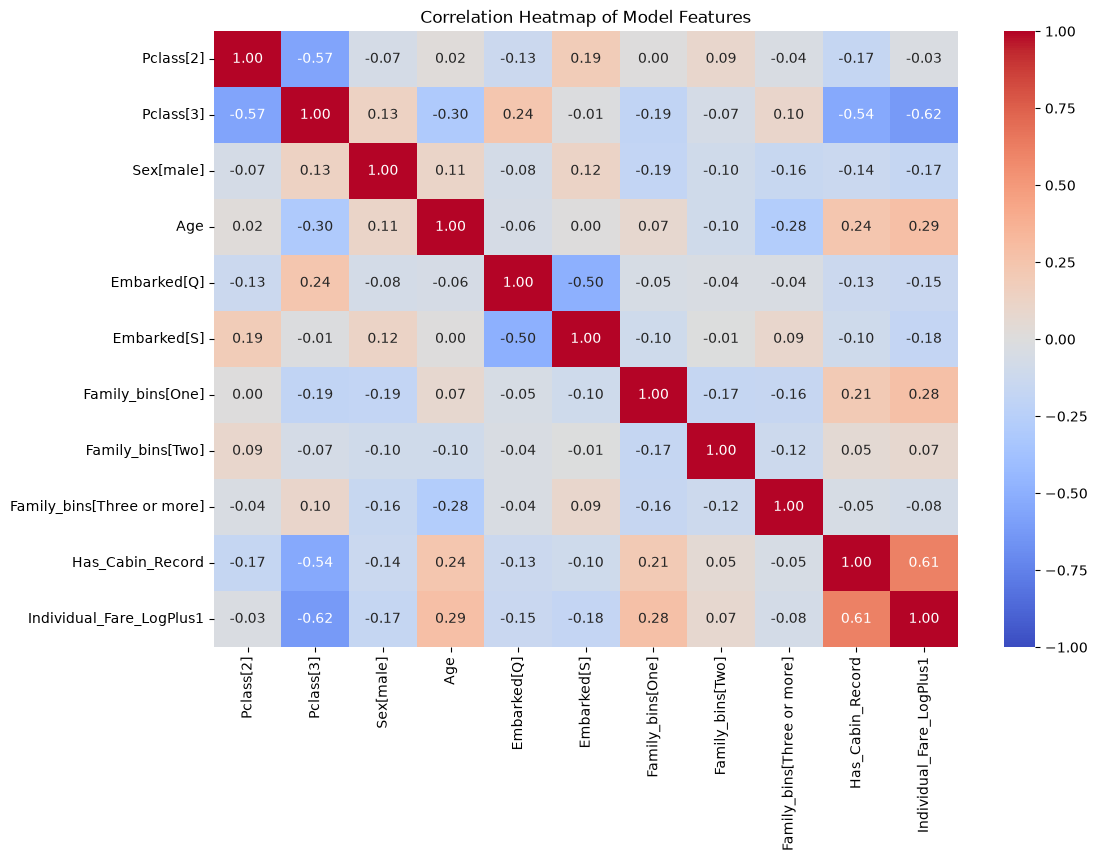

In [16]:
# Now, we are using Titanic_train_f, I want to see if there is some significant correlation between any of these variables
# Lets have a look here, according to Gemini we can just reuse X_LR_f here to make the correlation heatmap
X_plot = X_LR_f.drop(columns=['intercept'], errors='ignore')

plt.figure(figsize=(12, 8))
sns.heatmap(X_plot.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Model Features")
plt.show()

# Ok I thought about using VIF, but its categorical variables. I then found some method which uses Generalized VIF, 
# I read into it a bit and it makes sense but it looks like a bit of a headache to implement, you have to write
# a new function and its just annoying. So we are just gonna go with this which seems alright I guess.

Here is the results with ticks and circles to see the relevant ones:

<img src="images_titanic/Correlation of Predictor Variables.png" width="700">

We must watch out for:

- PClass3 with Has_Cabin_Record
- PClass3 with Individual_Fare_LogPlus1
- Individual_Fare_LogPlus1 with Has_Cabin_Record

In [17]:
#Titanic_train_LR_f.head(10)

# Alright lets relook at the Linear Regression model:
summarize(results_LR_f)

# It seems like Embarked can maybe be grouped into two categories? Maybe this is overfitting?
# To be honest, we could just remove it as neither part has P value that is statistically significant.

# But we maybe should start with removing Individual_Fare_LogPlus1, and/or Family_bins. Family Bins has the worse P value on BOTH counts, but it has less correlation.

# Lets try this:
# One model removing Family categories
# One model removing Individual_Fare_LogPlus1

# We then compare the number of good predictions which were made with cross validation, 5 bins again
# Maybe we should write some functions for this... ugh...

,coef,std err,z,P>|z|
intercept,2.4435,0.861,2.839,0.005
Pclass[2],-0.1492,0.416,-0.359,0.720
Pclass[3],-1.2448,0.455,-2.736,0.006
Sex[male],-2.6576,0.206,-12.922,0.000
Age,-0.0403,0.008,-5.029,0.000
Embarked[Q],-0.1320,0.389,-0.339,0.734
Embarked[S],-0.4477,0.242,-1.854,0.064
Family_bins[One],-0.1271,0.252,-0.504,0.615
Family_bins[Two],0.3783,0.290,1.305,0.192
Family_bins[Three or more],-1.1155,0.330,-3.379,0.001


In [18]:
# Function for fitting model and returnig results Linear Regression
def LR_Model_Fitter(dataframe):
    # We make a copy of the inputed dataframe and then remove the response.
    dataframe_LR_dummy = dataframe.copy()
    dataframe_LR_dummy = dataframe_LR_dummy.drop(columns='Survived')
    
    # We make the format? Idk what this part actually rn
    design_LR_dummy = MS(dataframe_LR_dummy)
    
    # This does some transformation onto the X part so we can make the model. Black box
    X_LR_dummy = design_LR_dummy.fit_transform(dataframe)
    
    # Makes the response in right format
    Y_LR_dummy = dataframe.Survived == 1
    
    glm_LR_dummy = sm.GLM(Y_LR_dummy, X_LR_dummy, family=sm.families.Binomial())
    
    results_LR_dummy = glm_LR_dummy.fit()
    
    return summarize(results_LR_dummy)


LR_Model_Fitter(Titanic_train_f)

,coef,std err,z,P>|z|
intercept,2.4435,0.861,2.839,0.005
Pclass[2],-0.1492,0.416,-0.359,0.720
Pclass[3],-1.2448,0.455,-2.736,0.006
Sex[male],-2.6576,0.206,-12.922,0.000
Age,-0.0403,0.008,-5.029,0.000
Embarked[Q],-0.1320,0.389,-0.339,0.734
Embarked[S],-0.4477,0.242,-1.854,0.064
Family_bins[One],-0.1271,0.252,-0.504,0.615
Family_bins[Two],0.3783,0.290,1.305,0.192
Family_bins[Three or more],-1.1155,0.330,-3.379,0.001


In [55]:
# Ok so a few things. I went and looked at how Gemini recommended I get cross validation scores, 
# and that was cool. For Cross-Validation, one needs to refit the model the same number of times
# as whatever the number of folds you want (in this case 5 times). But when I looked at how
# Gemini was doing the 5 fittings, I saw that it used sklearn and it seemed like way better
# So I asked it to write a function which just used sklearn to fit the original model, one for
# for consistency sake, 2 cause sklearn is a nice tool to learn, and 3 cause it just seems way
# cleaner. Ill keep my old code above, but below is all Gemini. A mix of emotions to see that this
# computer is better at maths than me, like sheesh. Oh well, move with the times I suppose.

# Also there was then an issue where the QDA part didnt have the coef_ attribute, which turned into a 
# several hour find realizing I didnt quite remember the models interior, but thats sorted for now.
# This was made basically with gemini. I did some tweaking initially but not much has survived lmao.

def Model_Fitter_Sklearn(dataframe, target_col='Survived', model_type='logistic', cv_folds=5):
    """
    Fits Logistic Regression, LDA, or QDA models, evaluates CV accuracy,
    and returns a summary DataFrame alongside the fitted model.
    """
    # 1. Separate features and target
    X_raw = dataframe.drop(columns=[target_col])
    y = dataframe[target_col]
    
    # 2. One-hot encode categorical features (dummy encoding with baseline)
    X = pd.get_dummies(X_raw, drop_first=True)
    
    # 3. Instantiate model
    model_type = model_type.lower()
    if model_type == 'logistic':
        model = LogisticRegression(max_iter=5000)
    elif model_type == 'lda':
        model = LinearDiscriminantAnalysis()
    elif model_type == 'qda':
        model = QuadraticDiscriminantAnalysis()
    else:
        raise ValueError("Invalid model_type! Choose 'logistic', 'lda', or 'qda'.")
    
    # 4. Perform K-Fold Cross Validation
    cv_scores = cross_val_score(model, X, y, cv=cv_folds, scoring='accuracy')
    
    # 5. Print CV metrics
    print("=" * 55)
    print(f"Model Type: {model_type.upper()}")
    print(f"{cv_folds}-Fold CV Accuracy Scores: {cv_scores.round(4)}")
    print(f"Mean CV Accuracy:           {cv_scores.mean():.4f}")
    print("=" * 55)
    
    # 6. Fit the final model on all provided training data
    model.fit(X, y)
    
    # 7. Construct Summary Table
    # ------------------------------------------------------------------
    # CASE A: Linear Models (Logistic Regression & LDA) -> Return Coefficients
    # ------------------------------------------------------------------
    if hasattr(model, 'coef_'):
        summary_df = pd.DataFrame({
            'Feature': X.columns,
            'Coefficient (Log-Odds)': model.coef_[0].round(4),
            'Odds Ratio': np.exp(model.coef_[0]).round(4)
        })
        
        # Add intercept if available
        if hasattr(model, 'intercept_'):
            intercept_val = model.intercept_[0]
            intercept_row = pd.DataFrame({
                'Feature': ['Intercept'],
                'Coefficient (Log-Odds)': [np.round(intercept_val, 4)],
                'Odds Ratio': [np.round(np.exp(intercept_val), 4)]
            })
            summary_df = pd.concat([intercept_row, summary_df], ignore_index=True)
            
    # ------------------------------------------------------------------
    # CASE B: Quadratic Model (QDA) -> Return Class Priors & Class Means
    # ------------------------------------------------------------------
    else:
        # Create a summary of class means (mu_k) for each feature
        means_df = pd.DataFrame(model.means_.T, columns=['Mean (Perished: Y=0)', 'Mean (Survived: Y=1)'])
        means_df.insert(0, 'Feature', X.columns)
        
        # Round the values for readability
        means_df['Mean (Perished: Y=0)'] = means_df['Mean (Perished: Y=0)'].round(4)
        means_df['Mean (Survived: Y=1)'] = means_df['Mean (Survived: Y=1)'].round(4)
        
        # Calculate the absolute difference to see which features separate classes best
        means_df['Absolute Difference'] = (means_df['Mean (Survived: Y=1)'] - means_df['Mean (Perished: Y=0)']).abs().round(4)
        
        print(f"\nQDA Class Priors (pi_k): Perished={model.priors_[0]:.4f}, Survived={model.priors_[1]:.4f}")
        summary_df = means_df
        
    return model, summary_df

In [56]:
# Alright, now we fit the models themselves:

Model_Fitter_Sklearn(Titanic_train_f, target_col='Survived', model_type='logistic', cv_folds=5)


Model Type: LOGISTIC
5-Fold CV Accuracy Scores: [0.7809 0.809  0.8202 0.8034 0.8531]
Mean CV Accuracy:           0.8133


(LogisticRegression(max_iter=5000),
                              Feature  Coefficient (Log-Odds)  Odds Ratio
 0                          Intercept                  3.5981     36.5284
 1                                Age                 -0.0992      0.9055
 2                   Has_Cabin_Record                  0.8708      2.3889
 3           Individual_Fare_LogPlus1                  0.3018      1.3523
 4                        Age_Squared                  0.0009      1.0009
 5                           Pclass_2                 -0.2894      0.7487
 6                           Pclass_3                 -1.2068      0.2992
 7                           Sex_male                 -2.3246      0.0978
 8                         Embarked_Q                  0.0492      1.0504
 9                         Embarked_S                 -0.4287      0.6513
 10                   Family_bins_One                 -0.0797      0.9234
 11                   Family_bins_Two                  0.2922      1.3393
 1

In [57]:
Model_Fitter_Sklearn(Titanic_train_f, target_col='Survived', model_type='lda', cv_folds=5)

Model Type: LDA
5-Fold CV Accuracy Scores: [0.7921 0.8146 0.8146 0.7978 0.8192]
Mean CV Accuracy:           0.8077


(LinearDiscriminantAnalysis(),
                              Feature  Coefficient (Log-Odds)  Odds Ratio
 0                          Intercept                  4.8730    130.7132
 1                                Age                 -0.1243      0.8831
 2                   Has_Cabin_Record                  0.9530      2.5935
 3           Individual_Fare_LogPlus1                  0.2522      1.2869
 4                        Age_Squared                  0.0012      1.0012
 5                           Pclass_2                 -0.5586      0.5720
 6                           Pclass_3                 -1.5053      0.2219
 7                           Sex_male                 -2.9906      0.0503
 8                         Embarked_Q                  0.1140      1.1207
 9                         Embarked_S                 -0.5167      0.5965
 10                   Family_bins_One                 -0.0809      0.9223
 11                   Family_bins_Two                  0.4031      1.4965
 12    

In [58]:
Model_Fitter_Sklearn(Titanic_train_f, target_col='Survived', model_type='qda', cv_folds=5)

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\marco.valenzuela\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\marco.valenzuela\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\marco.valenzuela\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\discriminant_analysis.py", line 1141, in fit
    raise linalg.LinAlgError(
    ...<3 lines>...
    )
numpy

In [23]:
# Ok now we need a function to test which columns to remove. The evaluation will be based off of the 
# CV score. We will reuse the function we already have, and iterate through it until we cant improve. 
# I used Gemini to make this. AI AI AI aaaaa well whatever life goes on (for now)

def Backward_Stepwise_Selection(dataframe, target_col='Survived', model_type='logistic', cv_folds=5):
    """
    Performs Parent-Level Backward Stepwise Selection using K-Fold CV by directly
    reusing the Model_Fitter_Sklearn helper function.
    Returns the final optimized DataFrame AND a list of dropped column names.
    """
    current_features = [col for col in dataframe.columns if col != target_col]
    dropped_features = []  # List to track removed columns
    
    # 1. Baseline Run with All Features
    print("=" * 55)
    print("INITIAL BASELINE FIT (ALL FEATURES)")
    print("=" * 55)
    base_model, _ = Model_Fitter_Sklearn(
        dataframe[current_features + [target_col]], 
        target_col=target_col, 
        model_type=model_type, 
        cv_folds=cv_folds
    )
    
    # Calculate baseline score directly to set our benchmark
    X_base = pd.get_dummies(dataframe[current_features], drop_first=True)
    y = dataframe[target_col]
    best_score = cross_val_score(base_model, X_base, y, cv=cv_folds, scoring='accuracy').mean()
    
    print(f"\n🚀 STARTING BACKWARD SELECTION [{model_type.upper()}]")
    print(f"Initial Benchmark Mean CV Accuracy: {best_score:.4f}\n")
    
    round_num = 1
    
    while len(current_features) > 1:
        best_candidate_score = -1
        best_candidate_to_drop = None
        
        print(f"--- Round {round_num}: Testing dropping each of {len(current_features)} parent features ---")
        
        # Test dropping each remaining parent feature one-by-one
        for feature in current_features:
            test_features = [f for f in current_features if f != feature]
            
            # Prepare dummy variables without the candidate feature
            X_test = pd.get_dummies(dataframe[test_features], drop_first=True)
            
            # Re-evaluate using the fitted estimator structure
            score = cross_val_score(base_model, X_test, y, cv=cv_folds, scoring='accuracy').mean()
            print(f"  - Try dropping '{feature}': Mean CV Accuracy = {score:.4f}")
            
            if score > best_candidate_score:
                best_candidate_score = score
                best_candidate_to_drop = feature
                
        # Decision Rule: Only permanently drop if CV score explicitly improves
        if best_candidate_score > best_score:
            improvement = best_candidate_score - best_score
            print(f"  => DROPPING '{best_candidate_to_drop}' (CV improved by +{improvement:.4f} to {best_candidate_score:.4f})\n")
            
            # Track and remove the dropped feature
            dropped_features.append(best_candidate_to_drop)
            current_features.remove(best_candidate_to_drop)
            
            best_score = best_candidate_score
            round_num += 1
        else:
            print(f"\n✅ STOPPING RULE: Dropping any remaining feature reduces CV accuracy below {best_score:.4f}.\n")
            break
            
    # Final Fit and Summary display using Model_Fitter_Sklearn on the winning feature subset
    print("=" * 55)
    print("FINAL OPTIMIZED MODEL RESULT")
    print("=" * 55)
    final_df = dataframe[current_features + [target_col]]
    final_model, final_summary = Model_Fitter_Sklearn(
        final_df, 
        target_col=target_col, 
        model_type=model_type, 
        cv_folds=cv_folds
    )
    
    print(f"\nDropped Features ({len(dropped_features)}): {dropped_features if dropped_features else 'None'}\n")
    
    return final_df, dropped_features

In [43]:
# We ran some tests below, and saw that LogReg was the best. However, after asking Gemini said I should consider adding some polynomial terms and interaction.
# I agree on both counts. 
# 

# I am curious as to why they chose PClass and Sex, as opposed to Sex and any other predictor column
# 
# Create an interaction column between Sex and Pclass
Titanic_train_f['Sex_Pclass_Interaction'] = Titanic_train_f['Sex'].astype(str).str.cat(
    'P' + Titanic_train_f['Pclass'].astype(str), 
    sep='_'
)

#  Titanic_train_f['Has_Cabin_Record_Individual_Fare_LogPlus1_Interaction'] = Titanic_train_f['']

Titanic_train_f['Age_Squared'] = Titanic_train_f['Age'] ** 2

In [59]:
# 1. Prepare design matrix X with dummy variables (including interactions)
X_raw = Titanic_train_f.drop(columns=['Survived'])
y = Titanic_train_f['Survived']
X = pd.get_dummies(X_raw, drop_first=True)

# 2. Separate data by class
X_perished = X[y == 0]  # Class 0
X_survived = X[y == 1]  # Class 1

# 3. Calculate sample covariance matrices
cov_perished = X_perished.cov()
cov_survived = X_survived.cov()

# 4. Extract diagonals (variances of each dummy feature per class)
diag_df = pd.DataFrame({
    'Feature': X.columns,
    'Var_Class0 (Perished)': np.diag(cov_perished).round(6),
    'Var_Class1 (Survived)': np.diag(cov_survived).round(6)
})

# 5. Highlight features with zero or near-zero variance (< 0.001)
diag_df['Zero_Var_Class0'] = diag_df['Var_Class0 (Perished)'] < 0.001
diag_df['Zero_Var_Class1'] = diag_df['Var_Class1 (Survived)'] < 0.001

print("=" * 65)
print("DIAGONAL VARIANCES OF CLASS COVARIANCE MATRICES")
print("=" * 65)
print(diag_df.to_string(index=False))

# 6. Check determinant / rank directly
print("\n" + "=" * 65)
print(f"Class 0 (Perished) Covariance Matrix Rank: {np.linalg.matrix_rank(cov_perished)} / {X.shape[1]}")
print(f"Class 1 (Survived) Covariance Matrix Rank: {np.linalg.matrix_rank(cov_survived)} / {X.shape[1]}")
print("=" * 65)

DIAGONAL VARIANCES OF CLASS COVARIANCE MATRICES
                         Feature  Var_Class0 (Perished)  Var_Class1 (Survived)  Zero_Var_Class0  Zero_Var_Class1
                             Age             160.472679             195.863913            False            False
                Has_Cabin_Record               0.108718               0.239493            False            False
        Individual_Fare_LogPlus1               0.467344               0.612844            False            False
                     Age_Squared          834038.864421          755964.813654            False            False
                        Pclass_2               0.145733               0.190968            False            False
                        Pclass_3               0.218858               0.228171            False            False
                        Sex_male               0.126002               0.218454            False            False
                      Embarked_Q               0

In [60]:
Titanic_train_f.head(20)

,Survived,Pclass,Sex,Age,Embarked,Family_bins,Has_Cabin_Record,Individual_Fare_LogPlus1,Sex_Pclass_Interaction,Age_Squared
0,0,3,male,22.0,S,One,0,2.110213,male_P3,484.0
1,1,1,female,38.0,C,One,1,4.280593,female_P1,1444.0
2,1,3,female,26.0,S,Zero,0,2.188856,female_P3,676.0
3,1,1,female,35.0,S,One,1,3.316003,female_P1,1225.0
4,0,3,male,35.0,S,Zero,0,2.202765,male_P3,1225.0
5,0,3,male,30.0,Q,Zero,0,2.246893,male_P3,900.0
6,0,1,male,54.0,S,Zero,1,3.967694,male_P1,2916.0
7,0,3,male,2.0,S,Three or more,0,1.835577,male_P3,4.0
8,1,3,female,27.0,S,Two,0,1.549921,female_P3,729.0
9,1,2,female,14.0,C,One,0,2.774799,female_P2,196.0


In [ ]:
# Now that they have been added, we try to refit and see how well we do:

Model_Fitter_Sklearn(Titanic_train_f, target_col='Survived', model_type='logistic', cv_folds=5)

c:\Users\marco.valenzuela\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\marco.valenzuela\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as s

Model Type: LOGISTIC
5-Fold CV Accuracy Scores: [0.7809 0.809  0.8202 0.8034 0.8531]
Mean CV Accuracy:           0.8133


c:\Users\marco.valenzuela\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


(LogisticRegression(max_iter=1000),
                              Feature  Coefficient (Log-Odds)  Odds Ratio
 0                          Intercept                  3.6051     36.7857
 1                                Age                 -0.0994      0.9054
 2                   Has_Cabin_Record                  0.8712      2.3898
 3           Individual_Fare_LogPlus1                  0.3010      1.3513
 4                        Age_Squared                  0.0009      1.0009
 5                           Pclass_2                 -0.2935      0.7456
 6                           Pclass_3                 -1.2094      0.2984
 7                           Sex_male                 -2.3239      0.0979
 8                         Embarked_Q                  0.0511      1.0525
 9                         Embarked_S                 -0.4294      0.6509
 10                   Family_bins_One                 -0.0789      0.9242
 11                   Family_bins_Two                  0.2908      1.3375
 1

In [48]:
# That last one gave us a score of 0.8133, a bit better. Lets try lda
Model_Fitter_Sklearn(Titanic_train_f, target_col='Survived', model_type='LDA', cv_folds=5)

Model Type: LDA
5-Fold CV Accuracy Scores: [0.7921 0.8146 0.8146 0.7978 0.8192]
Mean CV Accuracy:           0.8077


(LinearDiscriminantAnalysis(),
                              Feature  Coefficient (Log-Odds)  Odds Ratio
 0                          Intercept                  4.8730    130.7132
 1                                Age                 -0.1243      0.8831
 2                   Has_Cabin_Record                  0.9530      2.5935
 3           Individual_Fare_LogPlus1                  0.2522      1.2869
 4                        Age_Squared                  0.0012      1.0012
 5                           Pclass_2                 -0.5586      0.5720
 6                           Pclass_3                 -1.5053      0.2219
 7                           Sex_male                 -2.9906      0.0503
 8                         Embarked_Q                  0.1140      1.1207
 9                         Embarked_S                 -0.5167      0.5965
 10                   Family_bins_One                 -0.0809      0.9223
 11                   Family_bins_Two                  0.4031      1.4965
 12    

In [51]:
Model_Fitter_Sklearn(Titanic_train_f, target_col='Survived', model_type='qda', cv_folds=5)

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\marco.valenzuela\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\marco.valenzuela\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\marco.valenzuela\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\discriminant_analysis.py", line 1141, in fit
    raise linalg.LinAlgError(
    ...<3 lines>...
    )
numpy

In [ ]:
# To do: High leverage Points
# Outliers
# Collinearity
C:\Marcos stuff\ISLP\Stats mini projects\Titanic Kaggle\images_titanic\Correlation of Predictor Variables.png

Ok so some clarifications: 

LDA uses Bayes theorem and estimates of P(X=x), P(X=x|Y=k), P(Y=k) to estimate P(Y=k|X=x). It uses some clever differentiation and log application to find a decision boundary. It doesnt iterate, instead using the calculated means and variances of x_i at different classes k, and uses these in its equations to find P(Y=k|X=x). 

In LDA, we assume that the k classes share a covariance matrix. Due to this, in the decision boundary the quadratic matrix terms cancel out when comparing decision boundaries. 

But in QDA, each class has its own covariance matrix, and so when comparing decision boundaries they dont cancel and therefore matter.

Logistic regression works a bit different, 

$$\text{Pr}(Y = k \mid X = x) = \frac{e^{\beta_{k0} + \beta_{k1}x_1 + \dots + \beta_{kp}x_p}}{1 + \sum_{l=1}^{K-1} e^{\beta_{l0} + \beta_{l1}x_1 + \dots + \beta_{lp}x_p}} \tag{4.10}$$

for $k = 1, \dots, K-1$, and

$$\text{Pr}(Y = K \mid X = x) = \frac{1}{1 + \sum_{l=1}^{K-1} e^{\beta_{l0} + \beta_{l1}x_1 + \dots + \beta_{lp}x_p}}. \tag{4.11}$$

It is not hard to show that for $k = 1, \dots, K-1$,

$$\log \left( \frac{\text{Pr}(Y = k \mid X = x)}{\text{Pr}(Y = K \mid X = x)} \right) = \beta_{k0} + \beta_{k1}x_1 + \dots + \beta_{kp}x_p. \tag{4.12}$$

============================

Alright with that clarified, do we understand why we cant ask for parameters, but in the other cases we can?

What even are the parameters we were asking for before?



$